## Potable water classification
In this part, we are going to take a deeper look at the `pandas` package. It is usually abbreviated upon import as the `pd` package.

In [4]:
import pandas as pd
import numpy as np

### Load data

We may use `pandas` to conveniently load `csv` file (as well as `xlsx` file, if you want). And the resulting object is a `DataFrame`.

In [5]:
# Load the dataset
dataset_path = "D:\\primary coding files\\基础\\CSC1006\\lec04_code\\water_potability.csv"
data = pd.read_csv(dataset_path)
data

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


The printted `DataFrame` has already given us a good first idea of what the data looks like. A frequently used function after loading the dataset is `.describe()`

In [6]:
data.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


You may notice that the scale of different features vary dramatically.

From example, pH values are from 0 to 14, while `"Solids"` values are from 300 to 60000.

We will come back to this later in this tutorial.

### ``DataFrame`` and ``Series``

We have introduced `DataFrame` a little bit in our last tutorial. `pd.DataFrame` is great at manipulating data.

We can access a specific column through the key.

https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html

In [7]:
data["Potability"]

0       0
1       0
2       0
3       0
4       0
       ..
3271    1
3272    1
3273    1
3274    1
3275    1
Name: Potability, Length: 3276, dtype: int64

The resulting object is a `pd.Series`, which is similar to a Python dict.

Since we are going to build classification models, it is good to know if the label distribution is skewed or not.

In [8]:
data["Potability"].sum()

np.int64(1278)

So 1278 out of 3276 samples are possitive and the distribution is quite even.

We may call `.mean()` to calculate the mean of each column. 

In [9]:
data.mean()

ph                     7.080795
Hardness             196.369496
Solids             22014.092526
Chloramines            7.122277
Sulfate              333.775777
Conductivity         426.205111
Organic_carbon        14.284970
Trihalomethanes       66.396293
Turbidity              3.966786
Potability             0.390110
dtype: float64

### Data cleaning

The potable water dataset is the first actual dataset in this course with missing values.

We first check if the values are `null` using `.isnull()`, then call `.sum()` to calculate the number of `True`s.

In [10]:
data.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Missing values are more than common in practice and must be taken care of.

The simpliest way to deal with the missing values is to simply drop the sample. 

However, this practice may
- Introduce bias towards our dataset.
- Greatly reduce the size of our dataset.

Here, we fill the missing values with the mean values of the 

In [11]:
data = data.fillna(data.mean()) 

In [12]:
data.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

### Build models

We split the `potability` column from the full dataset, and use it as the labels.

The rest of the columns becomes the features.

In [13]:
X = data.drop(columns='Potability')  # Assuming 'label' is the target column
y = data['Potability']

We will try to use tree different models, including KNN, perceptron and logistic regression.

We will also use the accuracy score for evaluation, since the labels are evenly distributed.

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.metrics import accuracy_score

`train_test_split` supports `pd.DataFrame` as inputs, in addition to NumPy arrays.

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

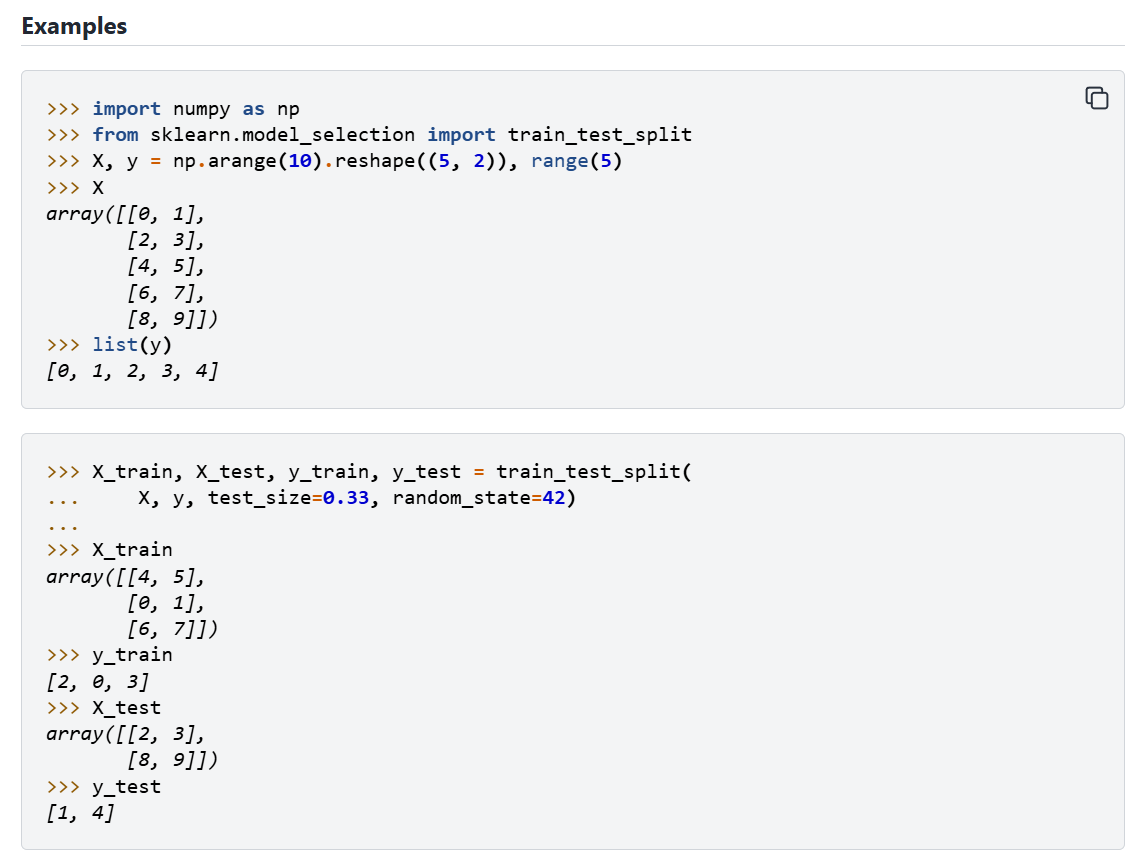

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

In [16]:
X_test

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
455,7.266595,176.853696,14859.059661,8.261778,327.172252,445.037456,19.923704,87.066131,3.357439
687,5.898726,198.310020,21148.241905,9.124900,326.254282,312.388586,13.042948,74.311619,4.899815
279,6.286807,258.300052,13777.376191,7.483258,328.680650,563.434775,16.460837,73.516654,4.104863
1167,7.080795,182.317256,30430.211752,6.151217,350.448584,479.957076,16.576565,58.675066,4.536123
940,8.966836,228.691355,16764.854765,7.137871,320.555995,456.426489,12.599998,77.330137,3.654355
...,...,...,...,...,...,...,...,...,...
1765,9.497261,124.482810,33681.330140,4.814656,427.184508,530.217008,19.970318,49.809841,5.242105
1785,6.047651,177.444264,28633.846385,8.174385,333.775777,386.661205,15.514930,30.556310,2.589868
2175,7.274757,195.118030,21496.745136,6.571090,360.697815,418.373582,11.382543,81.235608,4.271581
560,7.091886,221.191476,29091.207101,5.134960,333.775777,515.059986,19.578273,62.627330,5.116407


Compared to NumPy array, it is easier to see that the data is randomly shuffled.

In [17]:
X_train

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
1542,6.347020,97.280909,19743.148416,3.402682,305.431236,502.919013,15.094091,86.554168,4.526351
2776,4.762829,153.297018,22777.532069,6.841721,333.775777,522.736233,15.785509,86.128613,2.471786
1223,7.582942,185.045993,23072.780698,5.892273,297.505772,518.048524,12.038457,80.312558,4.164029
1923,7.463916,215.479068,27150.395400,7.782915,382.958737,403.703502,14.777092,56.956939,5.075844
1910,5.284810,148.862758,11130.211365,6.820469,335.660450,485.805431,13.773350,60.944343,3.990243
...,...,...,...,...,...,...,...,...,...
332,5.382489,240.018214,18189.394980,5.551990,397.700065,551.476202,12.818730,79.779911,4.173330
1293,7.293929,180.843125,15823.339374,7.721977,333.775777,457.520443,8.857599,37.734790,4.403250
3163,8.379513,164.168166,24409.096795,8.199017,333.775777,430.238921,19.349982,63.105234,3.749818
1104,7.746343,212.274645,21670.593663,8.458103,361.381325,457.014121,21.430293,43.188803,3.678686


Since all `sklearn` models have the same interface, we can first initialize all models and loop through them for the training.

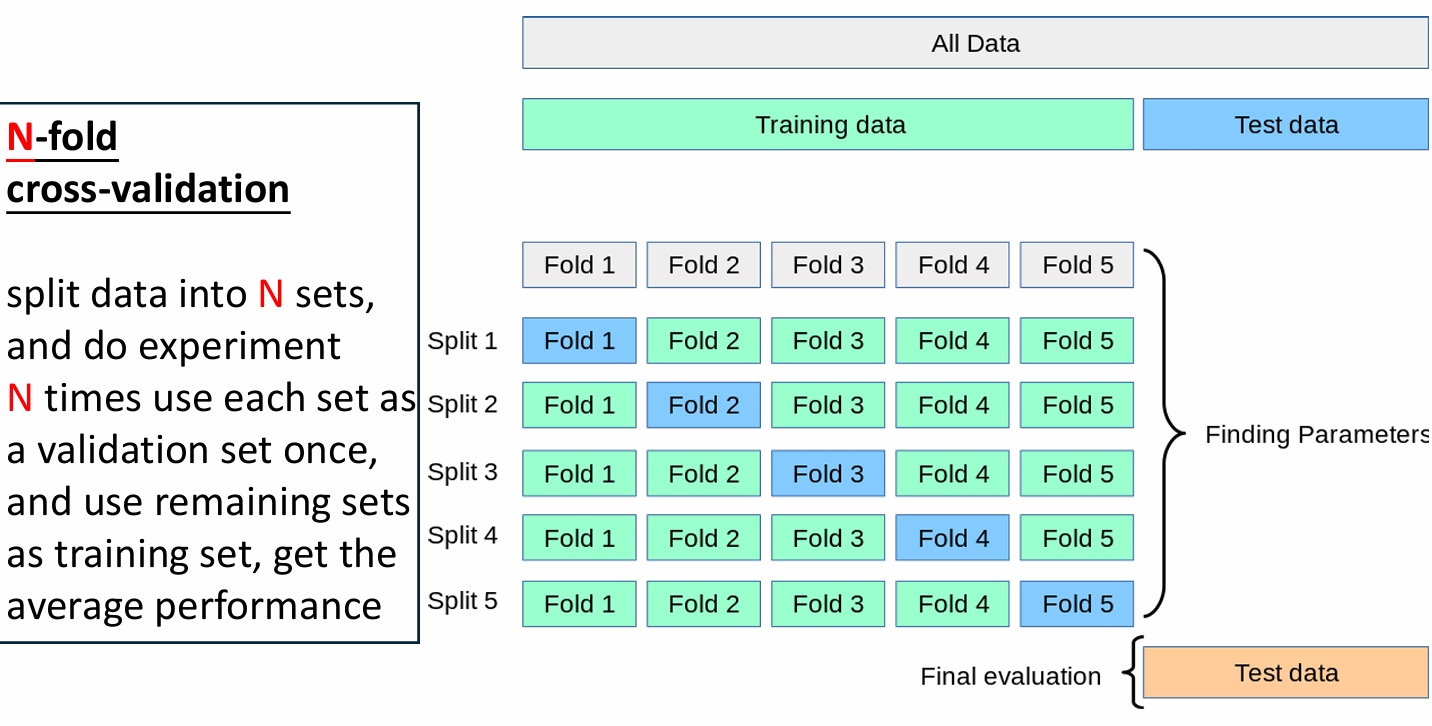

In [18]:
models = [
    KNeighborsClassifier(n_neighbors=3),
    Perceptron(random_state=22),
    LogisticRegression(random_state=15, max_iter=1000)
]

for model in models:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(accuracy_score(y_test, pred))

0.5548780487804879
0.4009146341463415
0.5975609756097561


d:\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


From the results, we see the the logistic model has the highest accuracy

### Standardize the data

The scale of different features vary dramatically, which could be harmful to the models.

See https://stats.stackexchange.com/questions/287425/why-do-you-need-to-scale-data-in-knn

![](https://github.com/user-attachments/assets/e87c5221-13cb-4f93-80b0-72b8a85b43eb)
![](https://github.com/user-attachments/assets/c4d522df-f7d9-42c6-a4d9-54bb3a36a025)

We can use `StandardScaler` from `sklearn` to help us standardize the data.

In [19]:
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit the scaler to the data and transform the data
X_standardized = scaler.fit_transform(X)

Let's make histgram plots to check that the data is indeed standardized.

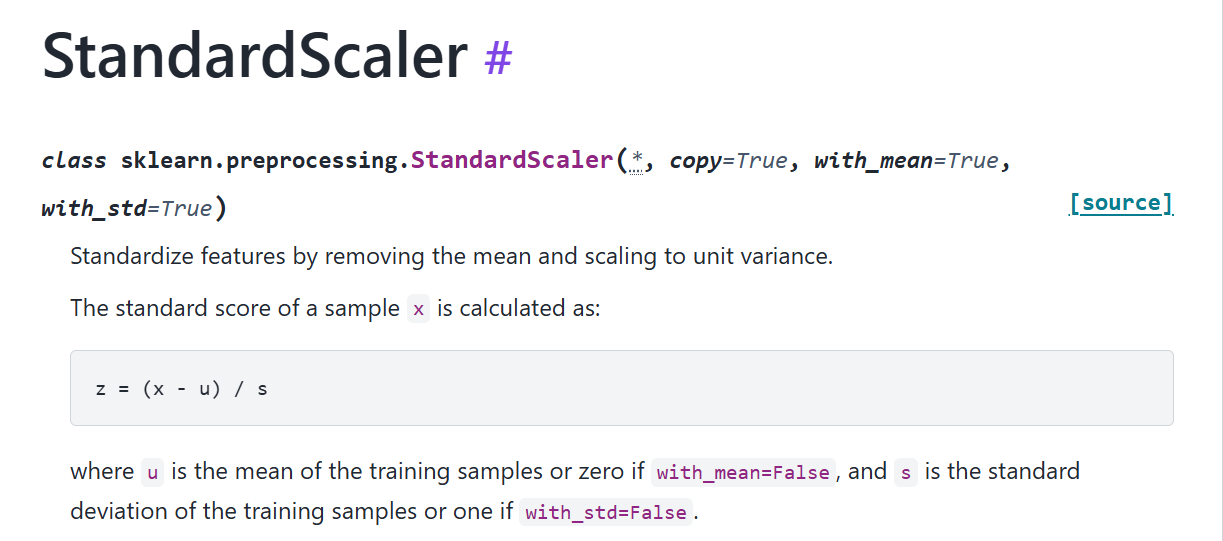

In [20]:
from matplotlib import pyplot as plt

In [21]:
X.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity'],
      dtype='object')

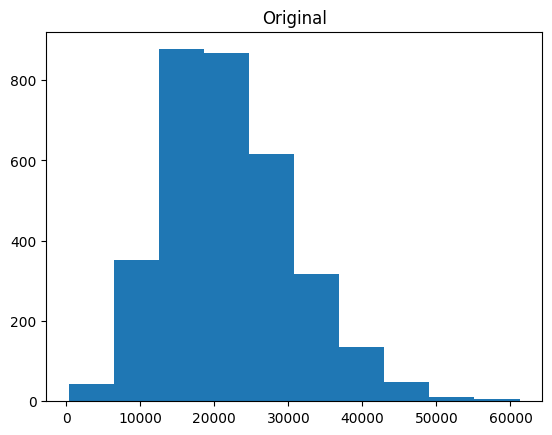

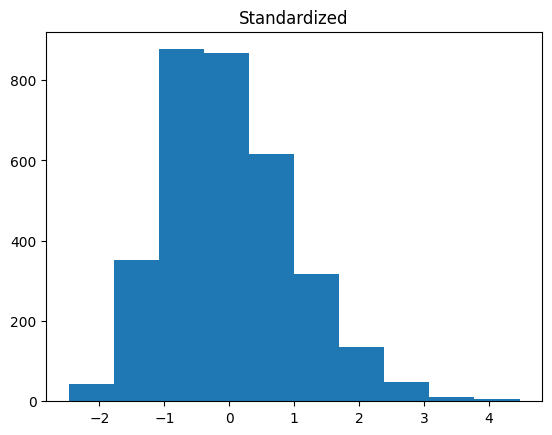

In [22]:
plt.hist(X["Solids"])
plt.title("Original")
plt.show()

plt.hist(X_standardized[:, 2])
plt.title("Standardized")
plt.show()

Create the training and test set using the standardized dataset, and then build the models again

In [23]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_standardized, y, test_size=0.2, random_state=19)

In [24]:
for model in models:
    model.fit(X_train2, y_train2)
    pred2 = model.predict(X_test2)
    print(accuracy_score(y_test2, pred2))

0.6036585365853658
0.44664634146341464
0.6128048780487805


We can see that the accuracy is increased.